# Compare performance on different splits

Two new splits were created: 
- `asl100_bottom`: 100 classes with fewest examples. See this [notebook.]('./100_fewest') 

In [ ]:


from code.results import CODE_DIR, CLASSES_PATH, WLASL_ROOT, LABELS_PATH, RUNS_PATH  # etc.

from pathlib import Path
from typing import List, Any
from pydantic import BaseModel
import pandas as pd
import json

# locals

from resulting import (
    print_json,
    RESULTS_DIR,
    load_config_and_find_runs,
    load_config,
    find_runs,
    basic_logger,
    modify,
    snap
)
from run_types import GenInfo
from stats import (
    AVAIL_SETS,
    AVAIL_SPLITS,
)
from visualise import get_all_sets, FrameVisualiser, printv
import logging
from models import avail_models


Please update your PyTorchVideo to latest master


FileNotFoundError: [Errno 2] No such file or directory: './info/wlasl_class_list.json'

## Setup:

Set variables for dataset loading

In [2]:
# all_classes = get_class_list()
cwd = RESULTS_DIR / 'dataset_analysis'
verbosity = 1
save_files = False
split_idx = 0 #change for different split
set_idx = 0 #change for different set
split_options: List[AVAIL_SPLITS] = ["asl100", "asl300", "asl1000", "asl2000", 'asl100_bottom', 'asl100_worst']
set_options: List[AVAIL_SETS] = ['train', 'test', 'val']
split_name: AVAIL_SPLITS = split_options[split_idx]
set_name: AVAIL_SETS = set_options[set_idx]
cls_index = 60
# all_classes = get_class_list()
all_sets = get_all_sets(split_name, verbosity=verbosity)
frame_viewer = FrameVisualiser(
    cls_index,
    all_sets,
    set_name,
    split_name,
    verbosity=verbosity
)
print_v = printv(verbosity)

### Frame viewer

See example frames

From: asl100S/train
Example videos for class: "doctor"
Instance: 1/13
Next example video path: ../data/WLASL/WLASL2000/17007.mp4


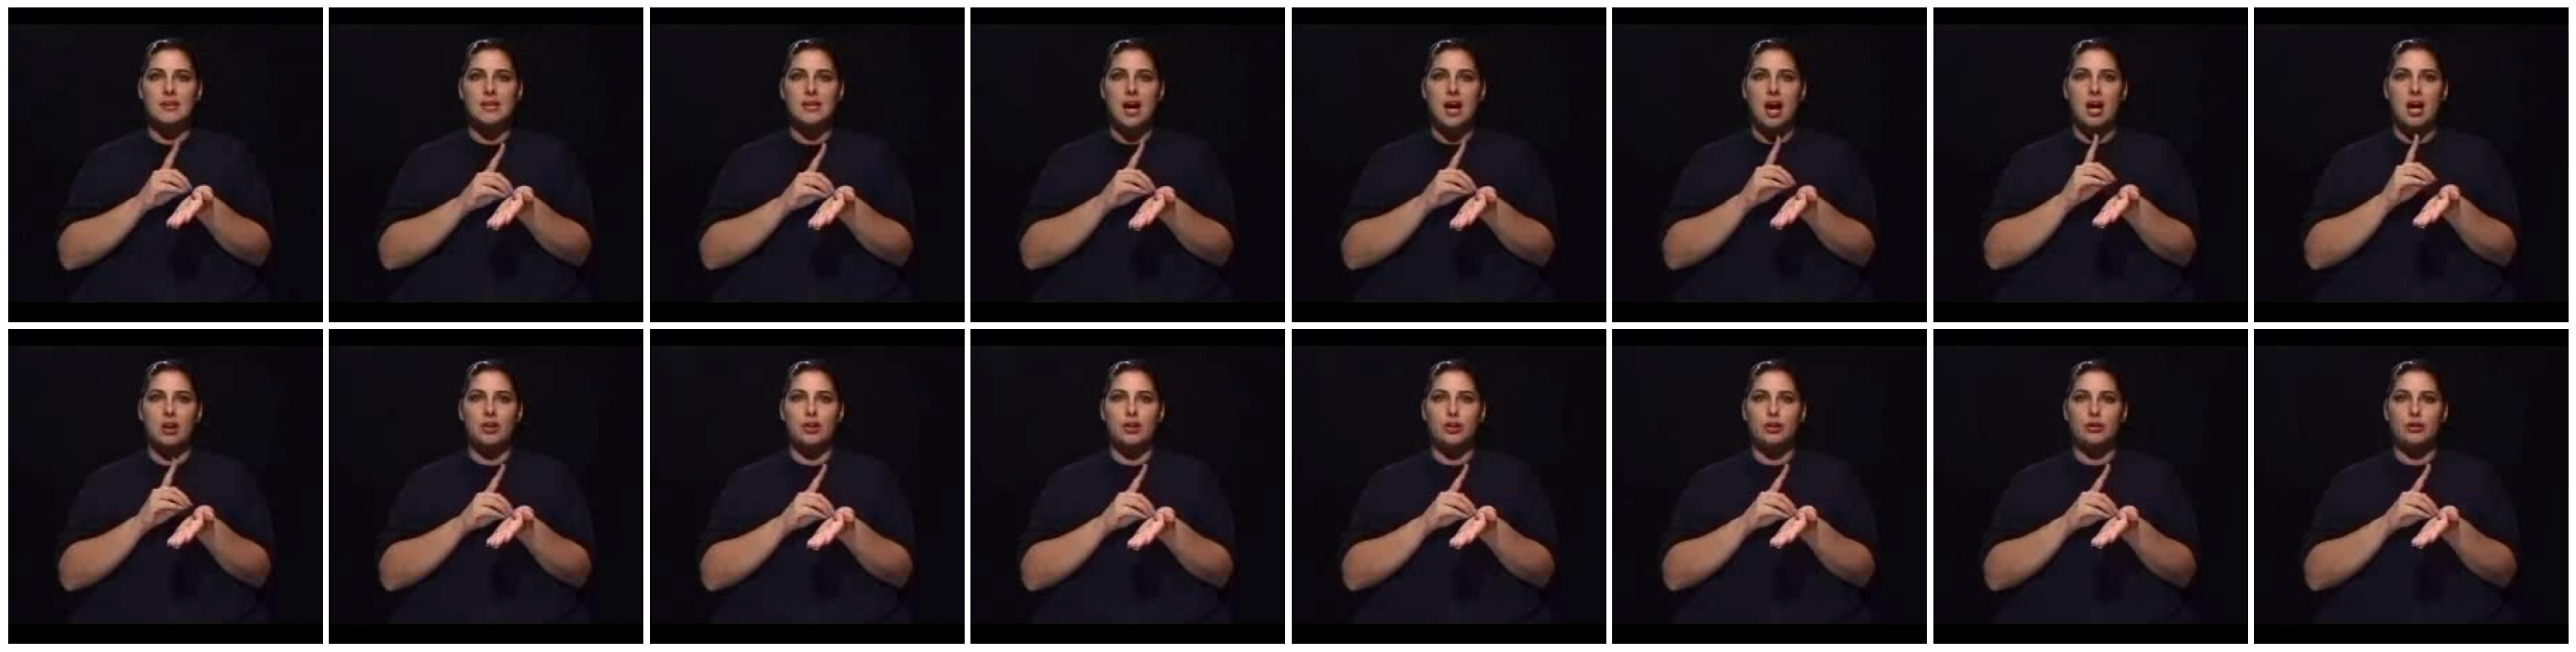

In [3]:
frame_viewer()

### Specifications of experiment

Use the provided path to load a config file, runs are matched against the specification

In [4]:
acc_cuttoff = 0
chosen_models = avail_models()
chosen_splits : list[AVAIL_SPLITS] = ['asl100', 'asl100_bottom', 'asl100_worst']

additional_modifications = {
    # 'results': {
    #     'best_val_acc': lambda x: x > acc_cuttoff
    # },
    # 'admin': {
    #     'model': lambda x: x in avail_models,
    #     # 'split': lambda x: x in avail_splits
    # }
    
    
}

def drop_max_wobble(temporal_aug: list) -> list:
    for item in temporal_aug:
        item.pop('max_wobble', None)
    return temporal_aug

ignore_keys = {
    'data': {
        'train_augs': {'temporal_aug': drop_max_wobble},
        'test_augs':  {'temporal_aug': drop_max_wobble},
    }
}


exclude_keys = [
    ['results', 'test_shuff'],
    ['results', 'check_name'],
]

def load_find(conf_path: Path) -> GenInfo:
    runs =  load_config_and_find_runs(
            conf_path,
            exclude=exclude_keys,
            extra_mods=additional_modifications,
            logging_level=logging.INFO
        )
    assert runs is not None, 'No runs found'
    return runs

In [ ]:
conf_path = Path('configfiles/asl100/MViTv2_S/exp016.toml')
assert conf_path.exists()
config = load_config(str(conf_path))

In [6]:
# print_json(modify(config, ignore_keys, basic_logger))

## Matched runs:

The config was chosen based on the best MViTv2_S model run. The same parameters were run across the new splits: `asl100_bottom` and `asl100_worst`.

In [7]:
runs = load_find(conf_path)

Loaded que state from /home/luke/Code/SLR/code/que/Runs.json
Found 4/166 runs matching the spec
Excluded 0 runs based on additional modifications


## Runs 16 frames:

Lets check how many runs there are that match that spec:

In [8]:
for run in runs['results']:
    print_json(run['admin'])
    print()
print(len(runs['results']))

{
    "model": "MViTv2_S",
    "dataset": "WLASL",
    "split": "asl100_worst",
    "save_path": "runs/asl100_worst/MViTv2_S/exp000/checkpoints",
    "seed": 42,
    "exp_no": "000",
    "recover": false,
    "config_path": "configfiles/asl100/MViTv2_S/exp016.toml",
    "weight_path": null
}

{
    "model": "MViTv2_S",
    "dataset": "WLASL",
    "split": "asl100_bottom",
    "save_path": "runs/asl100_bottom/MViTv2_S/exp000/checkpoints",
    "seed": 42,
    "exp_no": "000",
    "recover": true,
    "config_path": "configfiles/asl100/MViTv2_S/exp016.toml",
    "weight_path": null
}

{
    "model": "MViTv2_S",
    "dataset": "WLASL",
    "split": "asl100",
    "save_path": "runs/asl100/MViTv2_S/exp016/checkpoints",
    "seed": 42,
    "exp_no": "016",
    "recover": false,
    "config_path": "configfiles/asl100/MViTv2_S/exp016.toml",
    "weight_path": null
}

{
    "model": "MViTv2_S",
    "dataset": "WLASL",
    "split": "asl100",
    "save_path": "runs/asl100/MViTv2_S/exp017/checkpoin

## Runs 32 frames:

Lets check how many runs there are that match that spec:

<!-- Note there were 3 extra asl100s. We will take exp007 because it is used as a starting point for the asl300 run -->


In [9]:
# runs_32['results'] = runs_32['results'][:-3] 
for run in runs_3['results']:
    print_json(run['admin'])
    print()
print(len(runs_32['results']))

NameError: name 'runs_3' is not defined

## Now we can compare the runs

In [ ]:
avail_acc_types = ["top_k_average_per_class_acc", "top_k_per_instance_acc"]
acc_type = avail_acc_types[1]
set_name = 'test'

#### Need to modify the names of S3D or they all get mixed together

In [ ]:
df_format = []
for res in runs_16['results']: # + runs_32['results'] :
    model_name = res['admin']['model']
    if model_name == 'S3D':
        model_name += '_16'
    df_format.append(
        {'model': model_name, 'subset': res['admin']['split']} | {k : v for k, v in res['results'][set_name][acc_type].items()}
    )

for res in runs_32['results'] :
    model_name = res['admin']['model']
    if model_name == 'S3D':
        model_name += '_32'
    df_format.append(
        {'model': model_name, 'subset': res['admin']['split']} | {k : v for k, v in res['results'][set_name][acc_type].items()}
    )


df = pd.DataFrame(df_format)

In [ ]:
df = df.rename(columns={"top1": "Top-1", "top5": "Top-5", "top10": "Top-10"})
# df

In [ ]:
df['Top-1'] = df['Top-1'].apply(lambda x: f'{x*100:.2f}')
df['Top-5'] = df['Top-5'].apply(lambda x: f'{x*100:.2f}')
df['Top-10'] = df['Top-10'].apply(lambda x: f'{x*100:.2f}')

In [ ]:
subsets = ['asl100', 'asl300', 'asl1000', 'asl2000']
for set_name in subsets:
    subdf = df[df['subset'] == set_name]
    print(f'{set_name}'.capitalize())
    display(subdf.sort_values('Top-1', ascending=False))

Asl100


,model,subset,Top-1,Top-5,Top-10
23,MViTv2_B_32x3,asl100,78.29,90.31,95.74
17,MViTv2_B_32x3,asl100,77.52,93.41,96.51
18,MViTv2_B_32x3,asl100,74.42,92.25,96.12
7,MViTv2_S_16x4,asl100,73.64,91.47,96.12
24,MViTv2_B_32x3,asl100,73.26,92.64,95.74
21,S3D_32,asl100,64.73,86.82,92.25
22,S3D_32,asl100,63.18,89.53,93.80
19,S3D_32,asl100,60.08,86.43,91.86
20,S3D_32,asl100,59.30,84.11,91.47
26,S3D_32,asl100,59.30,86.43,92.64


Asl300


,model,subset,Top-1,Top-5,Top-10
16,MViTv2_B_32x3,asl300,67.07,88.77,92.22
6,MViTv2_S_16x4,asl300,60.93,88.02,92.51
11,S3D_32,asl300,40.12,64.97,76.50
2,S3D_16,asl300,35.33,64.82,76.05


Asl1000


,model,subset,Top-1,Top-5,Top-10
15,MViTv2_B_32x3,asl1000,56.77,83.48,89.66
5,MViTv2_S_16x4,asl1000,51.12,79.37,86.19
1,S3D_16,asl1000,30.38,59.97,70.58
10,S3D_32,asl1000,28.46,57.94,69.72


Asl2000


,model,subset,Top-1,Top-5,Top-10
14,MViTv2_B_32x3,asl2000,44.56,76.35,83.71
4,MViTv2_S_16x4,asl2000,39.91,70.61,79.65
9,S3D_32,asl2000,26.71,56.10,67.11
0,S3D_16,asl2000,23.38,51.23,64.19
13,MViTv2_B_32x3,asl2000,0.14,0.59,1.01
